In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler



In [3]:

df = pd.read_csv("train_set_.csv", sep=";")

In [4]:
df.head()

,ID,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


In [5]:
df["Mileage"] = df["Mileage"].str.replace(" kmpl", "").str.replace(" km/kg", "").astype(float)

In [6]:
df["Engine"] = df["Engine"].str.replace(" CC", "").astype(float)

In [7]:
df["Power"] = df["Power"].str.replace(" bhp", "")
df["Power"] = pd.to_numeric(df["Power"], errors="coerce")

In [8]:
df.isnull().sum()

ID                     0
Name                   0
Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage                2
Engine                35
Power                141
Seats                 41
Price                  0
dtype: int64

In [9]:
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())

df["Engine"] = df["Engine"].fillna(df["Engine"].median())

df["Seats"] = df["Seats"].fillna(df["Seats"].mode()[0])

df["Power"] = df.groupby("Engine")["Power"].transform(
    lambda x: x.fillna(x.median())
)

df["Power"] = df["Power"].fillna(df["Power"].median())

In [10]:
df.isnull().sum()

ID                   0
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

In [11]:
df[["Year","Kilometers_Driven","Mileage",
    "Engine","Power","Seats","Price"]].describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000
mean,2013.290356,58343.619528,18.267579,1581.620041,108.246361,5.280438,8.130381
std,3.271244,38054.637943,4.535039,548.862513,46.523518,0.789022,7.593306
min,1998.000000,171.000000,0.000000,72.000000,34.200000,0.000000,0.440000
25%,2011.000000,35000.000000,15.400000,1197.000000,74.000000,5.000000,3.450000
50%,2014.000000,54000.000000,18.480000,1461.000000,90.000000,5.000000,5.500000
75%,2016.000000,73653.500000,21.100000,1968.000000,126.320000,5.000000,9.250000
max,2019.000000,775000.000000,33.540000,5461.000000,550.000000,10.000000,40.000000


In [12]:
df[df["Mileage"] == 0]

,ID,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
14,14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0,2179.0,115.00,5.0,17.50
67,67,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,2019,15369,Diesel,Automatic,First,0.0,1950.0,194.00,5.0,35.67
79,79,Hyundai Santro Xing XL,Hyderabad,2005,87591,Petrol,Manual,First,0.0,1086.0,68.05,5.0,1.30
190,194,Honda City 1.5 GXI,Ahmedabad,2007,60006,Petrol,Manual,First,0.0,1461.0,84.80,5.0,2.95
224,229,Ford Figo Diesel,Bangalore,2015,70436,Diesel,Manual,First,0.0,1498.0,99.00,5.0,3.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5487,5647,Toyota Qualis Fleet A3,Mumbai,2001,227000,Diesel,Manual,Fourth & Above,0.0,2446.0,75.00,8.0,2.20
5709,5875,Mercedes-Benz C-Class Progressive C 220d,Ahmedabad,2019,4000,Diesel,Automatic,First,0.0,1950.0,194.00,5.0,35.00
5774,5943,Mahindra Jeep MM 540 DP,Chennai,2002,75000,Diesel,Manual,First,0.0,2112.0,90.00,6.0,1.70
5802,5972,Hyundai Santro Xing GL,Mumbai,2008,65000,Petrol,Manual,Second,0.0,1086.0,62.00,5.0,1.39


In [13]:

df.loc[df["Mileage"] == 0, "Mileage"] = np.nan

In [14]:
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())

In [15]:
df[df["Seats"] == 0]

,ID,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
3889,3999,Audi A4 3.2 FSI Tiptronic Quattro,Hyderabad,2012,125000,Petrol,Automatic,First,10.5,3197.0,90.0,0.0,18.0


In [16]:

df.loc[df["Seats"] == 0, "Seats"] = np.nan

In [17]:
df["Seats"] = df["Seats"].fillna(df["Seats"].mode()[0])

In [18]:
df[df["Engine"] < 500][["Name","Engine","Price"]]

,Name,Engine,Price
4322,Mahindra E Verito D4,72.0,13.0


In [19]:
df.loc[df["Engine"] < 500, "Engine"] = np.nan

In [20]:
df["Engine"] = df["Engine"].fillna(df["Engine"].median())

In [21]:
df[df["Power"] == 0]

,ID,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price


In [22]:
def extract_features(row):
    parts = row["Name"].split()

    return {
        "Brand": parts[0],
        "Model": " ".join(parts[1:3]),
        "Is_Luxury": 1 if parts[0] in LUXURY else 0,
        "Has_Turbo": 1 if "Turbo" in row["Name"] else 0
    }

In [23]:
def feature_engineering(df):

    # ========= 1. استخراج من Name =========
    def extract_name_features(row):
        parts = row["Name"].split()

        brand = parts[0]
        model = " ".join(parts[1:3]) if len(parts) > 2 else parts[1]
        has_turbo = 1 if "Turbo" in row["Name"] else 0

        return pd.Series([brand, model, has_turbo])

    df[["Brand", "Model", "Has_Turbo"]] = df.apply(extract_name_features, axis=1)

    df = df.drop("Name", axis=1)

    # ========= 2. تحويل 0 إلى NaN (قيم غير منطقية) =========
    df.loc[df["Mileage"] == 0, "Mileage"] = None
    df.loc[df["Seats"] == 0, "Seats"] = None
    df.loc[df["Engine"] < 500, "Engine"] = None

    # ========= 4. تعويض القيم المفقودة =========
    df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())
    df["Engine"] = df["Engine"].fillna(df["Engine"].median())
    df["Seats"] = df["Seats"].fillna(df["Seats"].mode()[0])

    df["Power"] = df.groupby("Engine")["Power"].transform(lambda x: x.fillna(x.median()))
    df["Power"] = df["Power"].fillna(df["Power"].median())

    # ========= 5. Luxury تلقائي =========
    brand_price = df.groupby("Brand")["Price"].mean()
    threshold = brand_price.quantile(0.75)

    luxury_brands = brand_price[brand_price >= threshold].index

    df["Is_Luxury"] = df["Brand"].apply(lambda x: 1 if x in luxury_brands else 0)

    # ========= 6. Outliers (Capping) =========
    numeric_cols = ["Year","Kilometers_Driven","Mileage","Engine","Power","Seats","Price"]

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)

    return df




In [24]:
df = feature_engineering(df)

In [25]:
df.head()

,ID,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model,Has_Turbo,Is_Luxury
0,0,Mumbai,2010.0,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,Maruti,Wagon R,0,0
1,1,Pune,2015.0,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,Creta 1.6,0,0
2,2,Chennai,2011.0,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,Honda,Jazz V,0,0
3,3,Chennai,2012.0,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,5.0,6.00,Maruti,Ertiga VDI,0,0
4,4,Coimbatore,2013.0,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi,A4 New,0,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5848 entries, 0 to 5847
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 5848 non-null   int64  
 1   Location           5848 non-null   object 
 2   Year               5848 non-null   float64
 3   Kilometers_Driven  5848 non-null   float64
 4   Fuel_Type          5848 non-null   object 
 5   Transmission       5848 non-null   object 
 6   Owner_Type         5848 non-null   object 
 7   Mileage            5848 non-null   float64
 8   Engine             5848 non-null   float64
 9   Power              5848 non-null   float64
 10  Seats              5848 non-null   float64
 11  Price              5848 non-null   float64
 12  Brand              5848 non-null   object 
 13  Model              5848 non-null   object 
 14  Has_Turbo          5848 non-null   int64  
 15  Is_Luxury          5848 non-null   int64  
dtypes: float64(7), int64(3),

In [27]:
cols_order = [
    "Brand",
    "Model",
    "Is_Luxury",
    "Has_Turbo",
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Location",
    "Fuel_Type",
    "Transmission",
    "Owner_Type",
    "Price"
]

df = df[cols_order]

In [28]:
df.head()

,Brand,Model,Is_Luxury,Has_Turbo,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Location,Fuel_Type,Transmission,Owner_Type,Price
0,Maruti,Wagon R,0,0,2010.0,72000.0,26.60,998.0,58.16,5.0,Mumbai,CNG,Manual,First,1.75
1,Hyundai,Creta 1.6,0,0,2015.0,41000.0,19.67,1582.0,126.20,5.0,Pune,Diesel,Manual,First,12.50
2,Honda,Jazz V,0,0,2011.0,46000.0,18.20,1199.0,88.70,5.0,Chennai,Petrol,Manual,First,4.50
3,Maruti,Ertiga VDI,0,0,2012.0,87000.0,20.77,1248.0,88.76,5.0,Chennai,Diesel,Manual,First,6.00
4,Audi,A4 New,1,0,2013.0,40670.0,15.20,1968.0,140.80,5.0,Coimbatore,Diesel,Automatic,Second,17.74


In [29]:
df["Brand"] = df["Brand"].astype("category").cat.codes
df["Model"] = df["Model"].astype("category").cat.codes

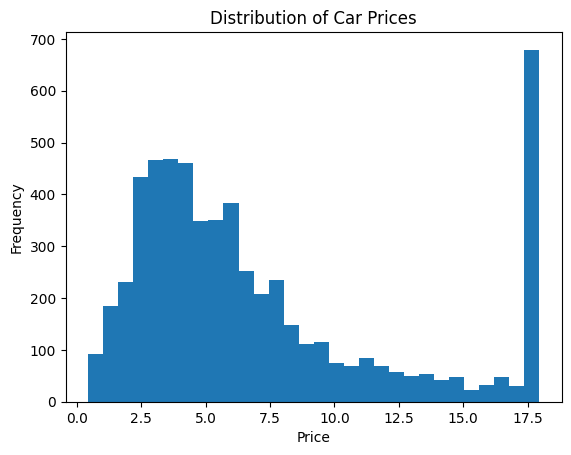

In [30]:

plt.figure()
plt.hist(df["Price"], bins=30)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

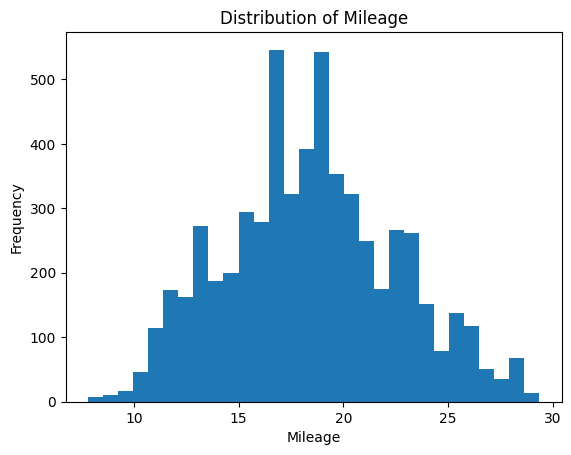

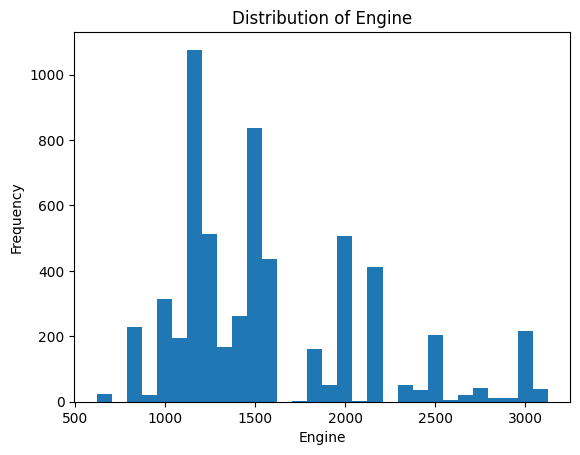

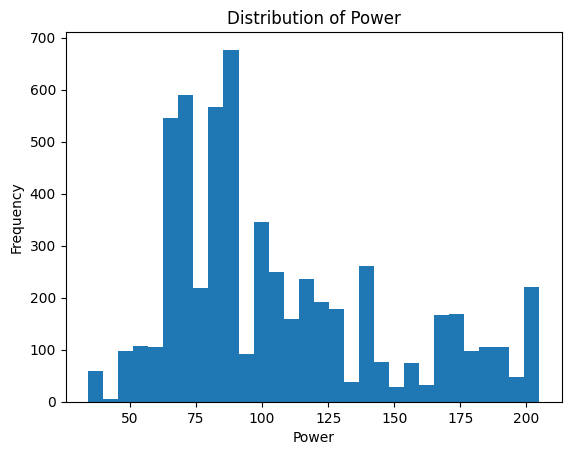

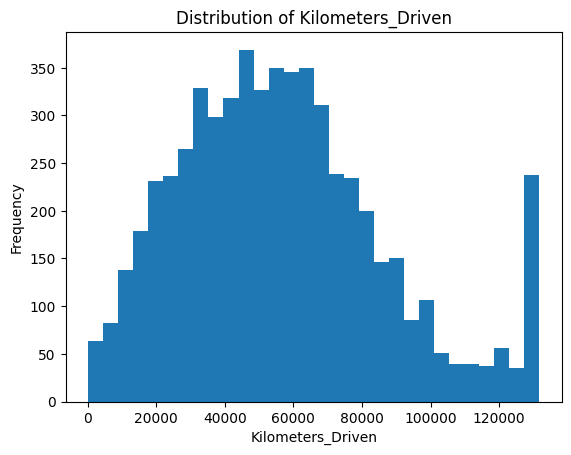

In [31]:
num_cols = ["Mileage", "Engine", "Power", "Kilometers_Driven"]

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

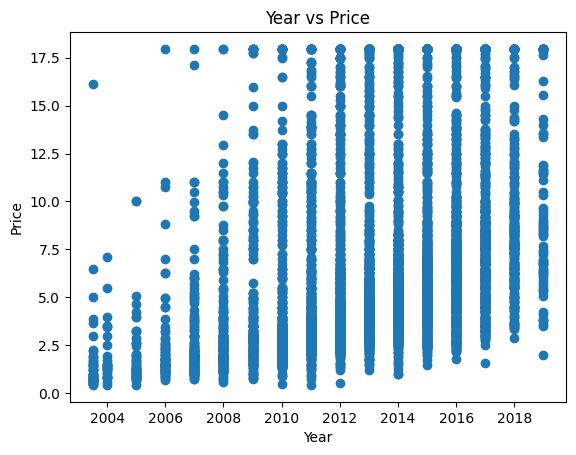

In [32]:
plt.figure()
plt.scatter(df["Year"], df["Price"])
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

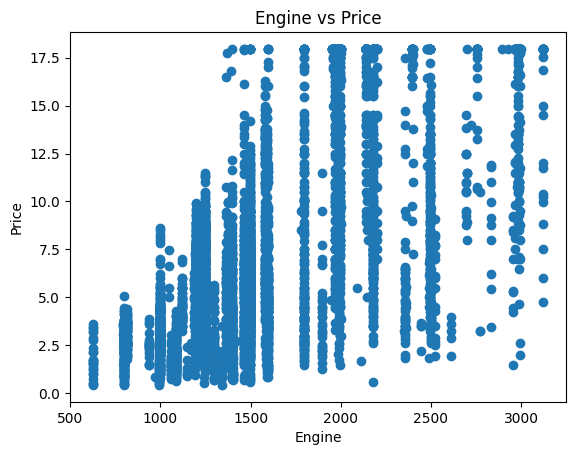

In [33]:
plt.figure()
plt.scatter(df["Engine"], df["Price"])
plt.title("Engine vs Price")
plt.xlabel("Engine")
plt.ylabel("Price")
plt.show()

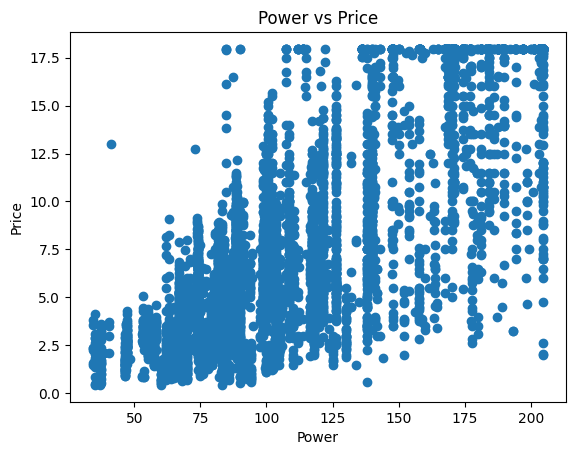

In [34]:
plt.figure()
plt.scatter(df["Power"], df["Price"])
plt.title("Power vs Price")
plt.xlabel("Power")
plt.ylabel("Price")
plt.show()

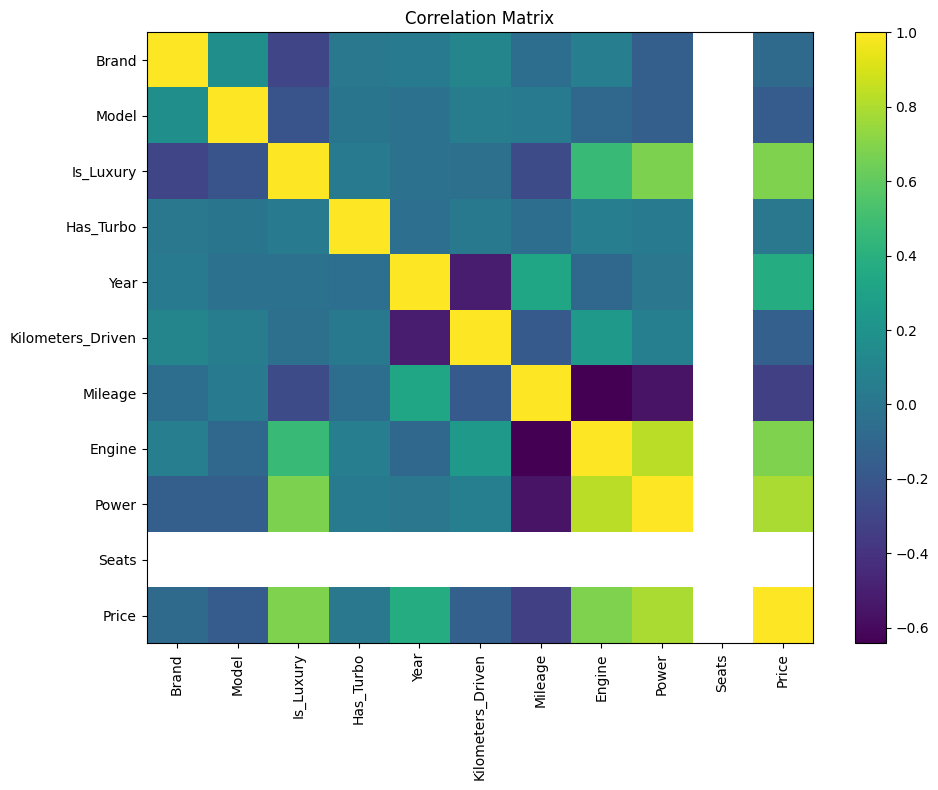

In [35]:

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

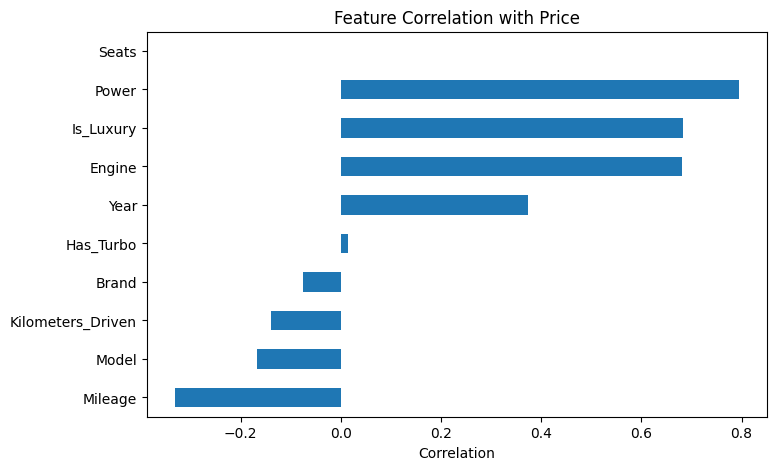

In [36]:

corr_with_price = (
    df.corr(numeric_only=True)["Price"]
    .drop("Price")
    .sort_values()
)

plt.figure(figsize=(8,5))
corr_with_price.plot(kind="barh")
plt.title("Feature Correlation with Price")
plt.xlabel("Correlation")
plt.show()

In [37]:


def prepare_nn_dataset(df, target_col="Price"):

    data = df.copy()

    # Frequency Encoding
    data["Model"] = data["Model"].map(
        data["Model"].value_counts()
    )

    # One-Hot Encoding
    data = pd.get_dummies(
        data,
        columns=[
            "Brand",
            "Location",
            "Fuel_Type",
            "Transmission",
            "Owner_Type"
        ],
        drop_first=True
    )

    # Features & Target
    X = data.drop(columns=[target_col])
    y = data[target_col]

    # Train Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler

In [39]:
def prepare_dataset(df):

    df = df.copy()

    df["Model"] = df["Model"].map(df["Model"].value_counts())

    df = pd.get_dummies(
        df,
        columns=[
            "Brand",
            "Location",
            "Fuel_Type",
            "Transmission",
            "Owner_Type"
        ],
        drop_first=True
    )

    return df

In [40]:
df = prepare_dataset(df)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5848 entries, 0 to 5847
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Model                      5848 non-null   int64  
 1   Is_Luxury                  5848 non-null   int64  
 2   Has_Turbo                  5848 non-null   int64  
 3   Year                       5848 non-null   float64
 4   Kilometers_Driven          5848 non-null   float64
 5   Mileage                    5848 non-null   float64
 6   Engine                     5848 non-null   float64
 7   Power                      5848 non-null   float64
 8   Seats                      5848 non-null   float64
 9   Price                      5848 non-null   float64
 10  Brand_1                    5848 non-null   bool   
 11  Brand_2                    5848 non-null   bool   
 12  Brand_3                    5848 non-null   bool   
 13  Brand_4                    5848 non-null   bool 

In [42]:
copy_df=df.copy()
X = copy_df.drop("Price", axis=1)
y = copy_df["Price"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

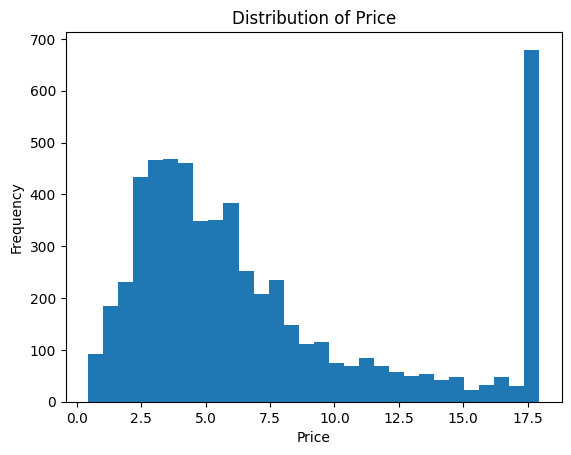

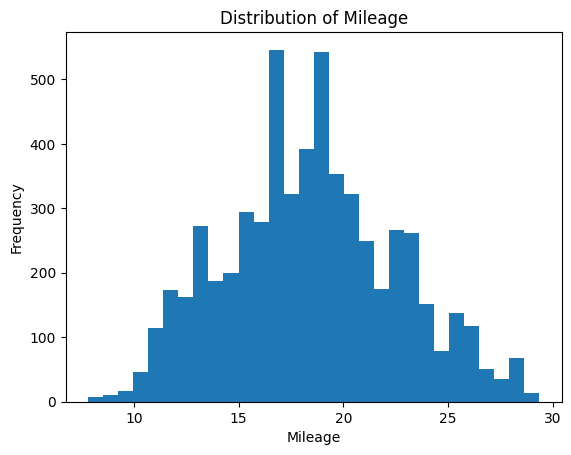

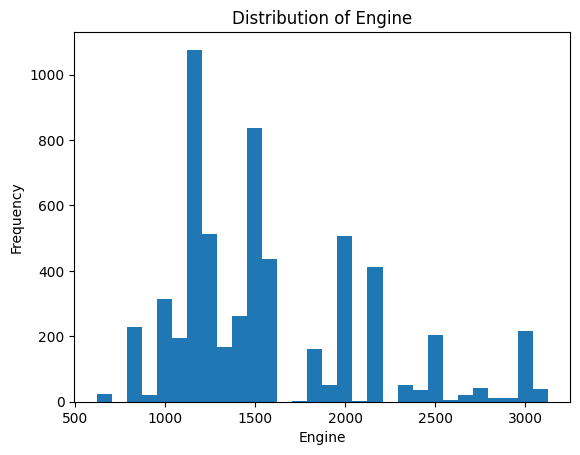

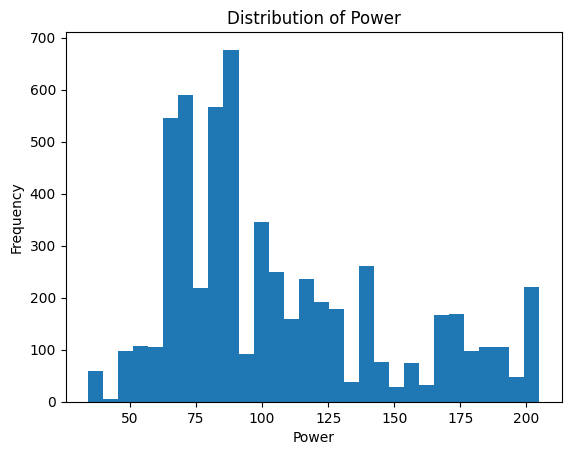

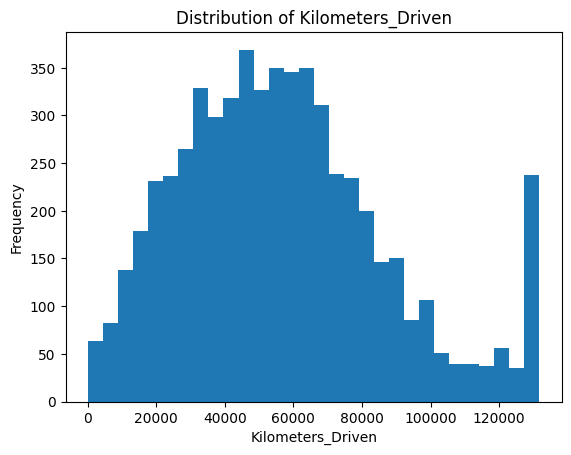

In [44]:
num_cols = ["Price","Mileage", "Engine", "Power", "Kilometers_Driven"]

for col in num_cols:
    plt.figure()
    plt.hist(copy_df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [45]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

print(df[numeric_cols].skew().sort_values(ascending=False))

Has_Turbo            38.206668
Is_Luxury             2.118642
Model                 1.220945
Price                 1.046187
Engine                1.025990
Power                 0.853922
Kilometers_Driven     0.614532
Mileage               0.161655
Seats                 0.000000
Year                 -0.703221
dtype: float64


In [46]:
df["Price"] = np.log1p(df["Price"])

print(df["Price"].skew())

0.14248380138226455


In [47]:
df.columns

Index(['Model', 'Is_Luxury', 'Has_Turbo', 'Year', 'Kilometers_Driven',
       'Mileage', 'Engine', 'Power', 'Seats', 'Price', 'Brand_1', 'Brand_2',
       'Brand_3', 'Brand_4', 'Brand_5', 'Brand_6', 'Brand_7', 'Brand_8',
       'Brand_9', 'Brand_10', 'Brand_11', 'Brand_12', 'Brand_13', 'Brand_14',
       'Brand_15', 'Brand_16', 'Brand_17', 'Brand_18', 'Brand_19', 'Brand_20',
       'Brand_21', 'Brand_22', 'Brand_23', 'Brand_24', 'Brand_25', 'Brand_26',
       'Brand_27', 'Brand_28', 'Location_Bangalore', 'Location_Chennai',
       'Location_Coimbatore', 'Location_Delhi', 'Location_Hyderabad',
       'Location_Jaipur', 'Location_Kochi', 'Location_Kolkata',
       'Location_Mumbai', 'Location_Pune', 'Fuel_Type_Diesel',
       'Fuel_Type_Electric', 'Fuel_Type_LPG', 'Fuel_Type_Petrol',
       'Transmission_Manual', 'Owner_Type_Fourth & Above', 'Owner_Type_Second',
       'Owner_Type_Third'],
      dtype='object')